In [1]:
!pip install torch torchvision matplotlib scikit-learn seaborn -q
print(" All libraries installed!")

 All libraries installed!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/grocery_project/results', exist_ok=True)
os.makedirs('/content/drive/MyDrive/grocery_project/models', exist_ok=True)
print(" Google Drive mounted & folders created!")

Mounted at /content/drive
 Google Drive mounted & folders created!


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

 Using device: cuda


In [4]:
SELECTED = {3: "Fresh Produce", 5: "Pet Food", 2: "Organic Items",
            7: "Farm Products", 9: "Packaged Goods"}
LABEL_MAP  = {orig: new for new, orig in enumerate(SELECTED.keys())}
CLASS_NAMES = list(SELECTED.values())

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("⬇️ Downloading dataset...")
trainset = CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
testset  = CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_indices = [i for i, (_, l) in enumerate(trainset) if l in SELECTED]
test_indices  = [i for i, (_, l) in enumerate(testset)  if l in SELECTED]

train_loader = DataLoader(Subset(trainset, train_indices), batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(Subset(testset,  test_indices),  batch_size=64, shuffle=False, num_workers=2)

print(f" Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
print(f" Classes: {CLASS_NAMES}")

⬇️ Downloading dataset...


100%|██████████| 170M/170M [06:08<00:00, 463kB/s]


 Train batches: 391, Test batches: 79
 Classes: ['Fresh Produce', 'Pet Food', 'Organic Items', 'Farm Products', 'Packaged Goods']


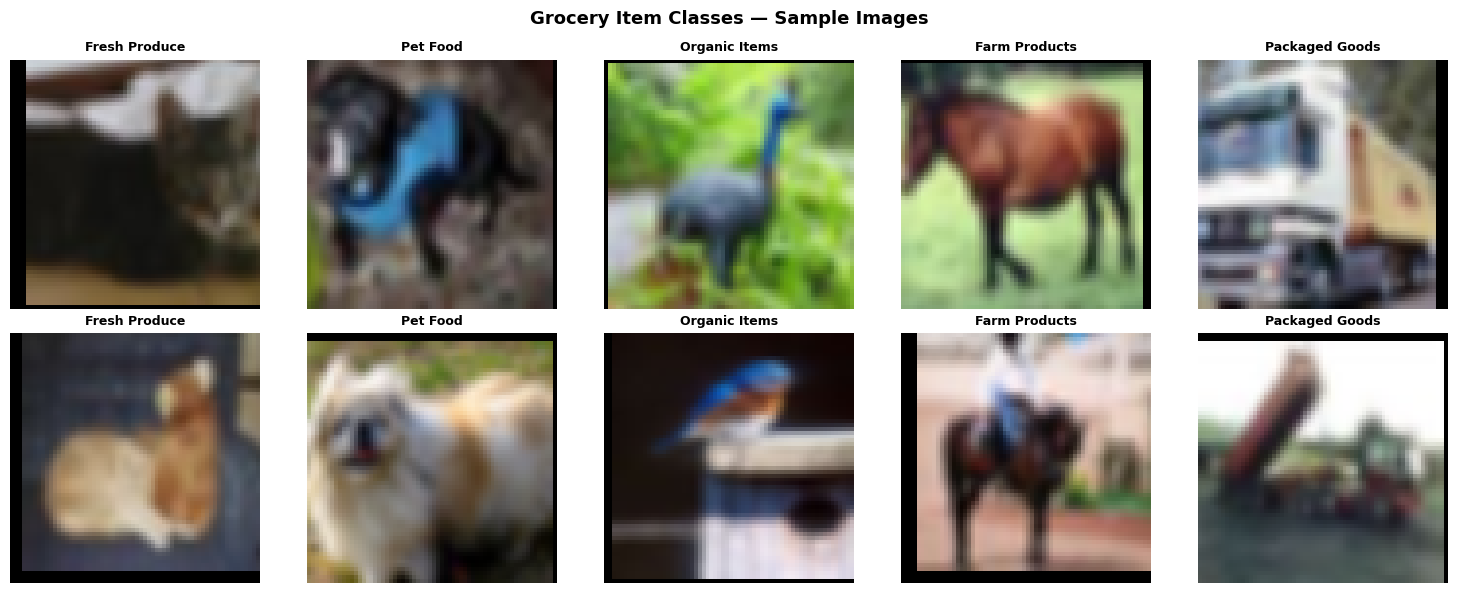

 Sample grid saved to Drive!


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
cifar_labels = list(SELECTED.keys())

for col, (cifar_lbl, class_name) in enumerate(SELECTED.items()):
    samples = [(img, lbl) for img, lbl in
               [trainset[i] for i in range(500)] if lbl == cifar_lbl][:2]
    for row, (img, _) in enumerate(samples):
        ax = axes[row][col]
        ax.imshow(img.permute(1, 2, 0).numpy() * 0.5 + 0.5)
        ax.set_title(class_name, fontsize=9, fontweight='bold')
        ax.axis('off')

plt.suptitle('Grocery Item Classes — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grocery_project/results/sample_grid.png', dpi=100)
plt.show()
print(" Sample grid saved to Drive!")

In [7]:
class GroceryClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(GroceryClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = GroceryClassifier(num_classes=5).to(device)
print(f" Model built! Parameters: {sum(p.numel() for p in model.parameters()):,}")

 Model built! Parameters: 2,238,757


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 10
train_losses, test_losses, test_accuracies = [], [], []

print("Training started...\n")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        labels = torch.tensor([LABEL_MAP[l.item()] for l in labels])
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total, test_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            labels = torch.tensor([LABEL_MAP[l.item()] for l in labels])
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            test_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    avg_train = running_loss / len(train_loader)
    avg_test  = test_loss  / len(test_loader)
    train_losses.append(avg_train)
    test_losses.append(avg_test)
    test_accuracies.append(acc)
    scheduler.step()
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}] | Train: {avg_train:.4f} | Test: {avg_test:.4f} | Acc: {acc:.2f}%")

print(f"\n Best Accuracy: {max(test_accuracies):.2f}%")

Training started...

Epoch [ 1/10] | Train: 1.4018 | Test: 1.1201 | Acc: 55.16%
Epoch [ 2/10] | Train: 1.2013 | Test: 1.0298 | Acc: 58.52%
Epoch [ 3/10] | Train: 1.1429 | Test: 0.9739 | Acc: 60.30%
Epoch [ 4/10] | Train: 1.1194 | Test: 0.9476 | Acc: 61.44%
Epoch [ 5/10] | Train: 1.0787 | Test: 0.9078 | Acc: 64.06%
Epoch [ 6/10] | Train: 1.0248 | Test: 0.8493 | Acc: 65.84%
Epoch [ 7/10] | Train: 1.0048 | Test: 0.8452 | Acc: 66.30%
Epoch [ 8/10] | Train: 0.9796 | Test: 0.8167 | Acc: 67.44%
Epoch [ 9/10] | Train: 0.9581 | Test: 0.7927 | Acc: 68.94%
Epoch [10/10] | Train: 0.9392 | Test: 0.7847 | Acc: 69.02%

🎉 Best Accuracy: 69.02%


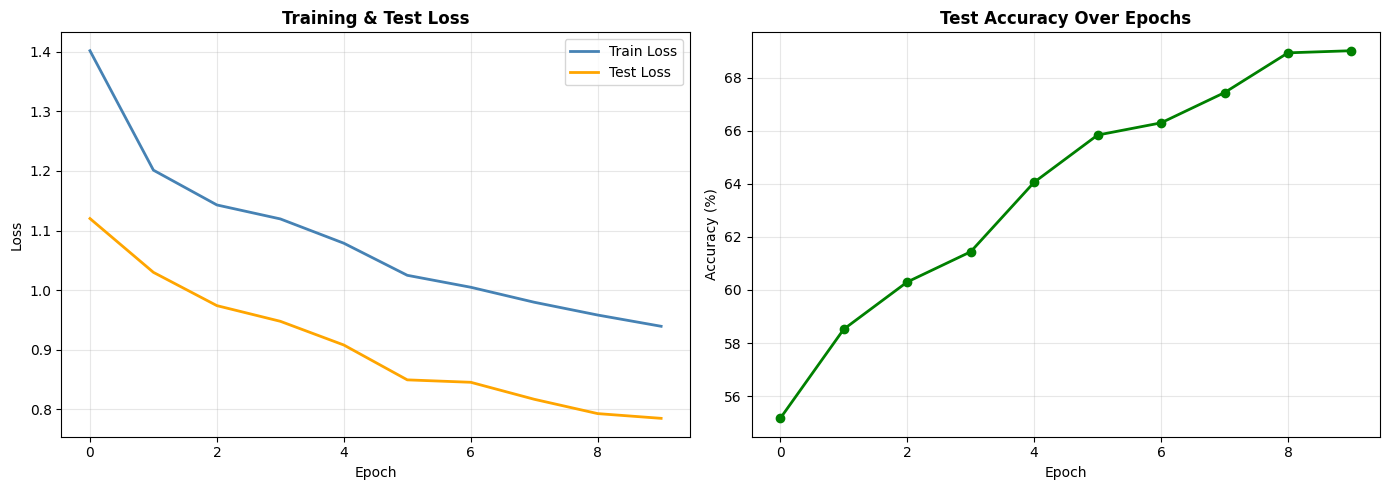

 Training curves saved!


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(test_losses,  label='Test Loss',  color='orange',    linewidth=2)
ax1.set_title('Training & Test Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(test_accuracies, color='green', linewidth=2, marker='o')
ax2.set_title('Test Accuracy Over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grocery_project/results/training_curves.png', dpi=100)
plt.show()
print(" Training curves saved!")

In [10]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'label_map': LABEL_MAP,
    'best_accuracy': max(test_accuracies),
}, '/content/drive/MyDrive/grocery_project/models/grocery_classifier.pth')

print("Model saved to Google Drive!")
print(f" Best Accuracy: {max(test_accuracies):.2f}%")

Model saved to Google Drive!
 Best Accuracy: 69.02%


 Overall Accuracy: 69.02%

                precision    recall  f1-score   support

 Fresh Produce       0.50      0.58      0.54      1000
      Pet Food       0.58      0.56      0.57      1000
 Organic Items       0.75      0.62      0.68      1000
 Farm Products       0.77      0.75      0.76      1000
Packaged Goods       0.87      0.94      0.90      1000

      accuracy                           0.69      5000
     macro avg       0.69      0.69      0.69      5000
  weighted avg       0.69      0.69      0.69      5000



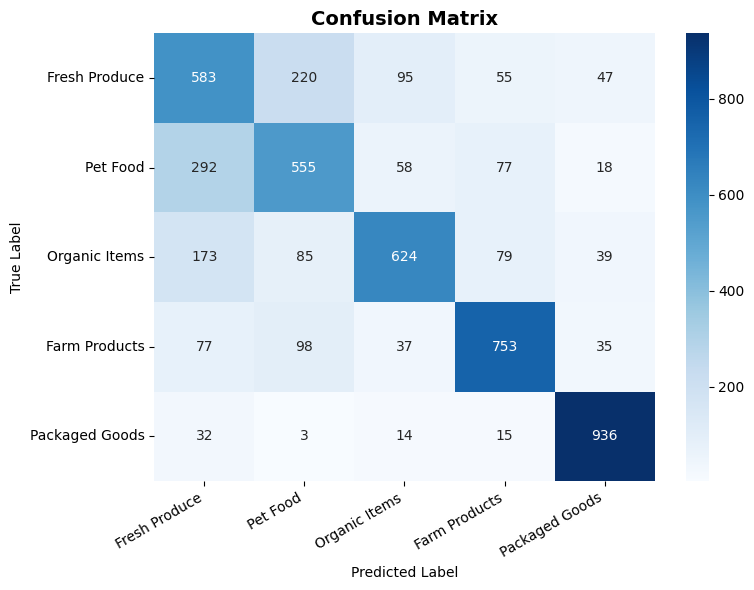

 Confusion matrix saved!


In [11]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        labels_mapped = torch.tensor([LABEL_MAP[l.item()] for l in labels])
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_mapped.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
accuracy   = (all_preds == all_labels).mean() * 100

print(f" Overall Accuracy: {accuracy:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d',
            cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grocery_project/results/confusion_matrix.png', dpi=100)
plt.show()
print(" Confusion matrix saved!")

In [13]:
report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)
with open('/content/drive/MyDrive/grocery_project/results/metrics.txt', 'w') as f:
    f.write("GROCERY CLASSIFIER — RESULTS\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"Overall Accuracy: {accuracy:.2f}%\n\n")
    f.write(report)

print("Metrics saved!")


Metrics saved!
